In [9]:
def get_clf_eval(y_test,pred=None,pred_proba=None):
    confusion = confusion_matrix(y_test,pred)
    accuracy = accuracy_score(y_test,pred)
    precision = precision_score(y_test,pred)
    recall= recall_score(y_test, pred)
    f1=f1_score(y_test,pred)
        
    #roc-auc 추가
    roc_auc=roc_auc_score(y_test,pred_proba)
    print('오차 행렬')
    print(confusion)
    print('정확도:',accuracy,'정밀도',precision,'재현율',recall,'F1',f1,'AUC',roc_auc)

### 피마 인디언 당뇨병 예측

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_auc_score
from sklearn.metrics import f1_score,confusion_matrix,precision_recall_curve,roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

diabetes_data=pd.read_csv('diabetes.csv')
print(diabetes_data['Outcome'].value_counts())
diabetes_data.head(3)

0    500
1    268
Name: Outcome, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [11]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [12]:
#피처 데이터 세트 X, 레이블 데이터 세트 y 추출
#맨 끝이 Outcome 칼럼으로 레이블 값임 칼림 위치 -1을 이용해 추출
X= diabetes_data.iloc[:,:-1]
y= diabetes_data.iloc[:,-1]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=156,stratify=y)

#로지스틱 회귀로 학습 , 예측 및 평가 수행
lr_clf = LogisticRegression()
lr_clf.fit(X_train,y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:,1]

get_clf_eval(y_test,pred,pred_proba)


오차 행렬
[[88 12]
 [23 31]]
정확도: 0.7727272727272727 정밀도 0.7209302325581395 재현율 0.5740740740740741 F1 0.6391752577319588 AUC 0.7918518518518518


C:\Users\dudtj\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


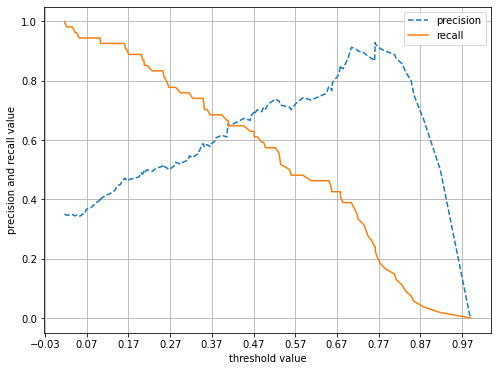

In [13]:
def precision_recall_curve_plot(y_test,pred_proba_c1):
    precisions,recalls,thresholds = precision_recall_curve(y_test,pred_proba_c1)
    
    plt.figure(figsize=(8,6))
    thresholds_boundary = thresholds.shape[0]
    plt.plot(thresholds,precisions[0:thresholds_boundary],linestyle='--',label='precision')
    plt.plot(thresholds,recalls[0:thresholds_boundary],label='recall')
    
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start,end,0.1),2))
    
    plt.xlabel('threshold value'); plt.ylabel('precision and recall value')
    plt.legend(); plt.grid()
    plt.show()
    
pred_proba_c1 = lr_clf.predict_proba(X_test)[:,1]
precision_recall_curve_plot(y_test,pred_proba_c1)

두 개의 지표 모두 0.7이 안 되는 수치로 보인다.

In [14]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


(array([  5.,   0.,   4.,  32., 156., 211., 163.,  95.,  56.,  46.]),
 array([  0. ,  19.9,  39.8,  59.7,  79.6,  99.5, 119.4, 139.3, 159.2,
        179.1, 199. ]),
 <BarContainer object of 10 artists>)

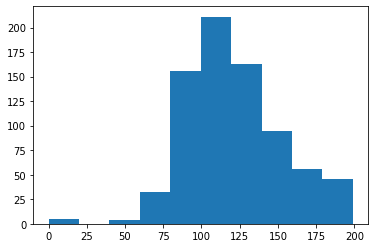

In [15]:
plt.hist(diabetes_data['Glucose'],bins=10)

In [17]:
zero_features = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

total_count = diabetes_data['Glucose'].count()

for feature in zero_features:
    zero_count = diabetes_data[diabetes_data[feature]==0][feature].count()
    print(feature,'0 건수는',zero_count,'퍼센트는',100*zero_count/total_count,'%')

Glucose 0 건수는 5 퍼센트는 0.6510416666666666 %
BloodPressure 0 건수는 35 퍼센트는 4.557291666666667 %
SkinThickness 0 건수는 227 퍼센트는 29.557291666666668 %
Insulin 0 건수는 374 퍼센트는 48.697916666666664 %
BMI 0 건수는 11 퍼센트는 1.4322916666666667 %


zero_features 리스트 내부에 저장된 개별 피처들에 대해서 0값을 평균 값으로 대체

In [18]:
mean_zero_features= diabetes_data[zero_features].mean()
diabetes_data[zero_features]=diabetes_data[zero_features].replace(0,mean_zero_features)

In [19]:
X= diabetes_data.iloc[:,:-1]
y= diabetes_data.iloc[:,-1]

#StandardScaler 클래스를 이용해 피처 데이터 세트에 일괄적으로 스케일링 적용
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=156,stratify=y)

#로지스틱 회귀로 학습 , 예측 및 평가 수행
lr_clf = LogisticRegression()
lr_clf.fit(X_train,y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:,1]

get_clf_eval(y_test,pred,pred_proba)

오차 행렬
[[89 11]
 [22 32]]
정확도: 0.7857142857142857 정밀도 0.7441860465116279 재현율 0.5925925925925926 F1 0.6597938144329897 AUC 0.8468518518518519


C:\Users\dudtj\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
from sklearn.preprocessing import Binarizer
def get_clf_eval(y_test,pred):
    confusion = confusion_matrix(y_test,pred)
    accuracy = accuracy_score(y_test,pred)
    precision = precision_score(y_test,pred)
    recall= recall_score(y_test,pred)
    print('오차행렬\n',confusion)
    print('정확도:',accuracy,'정밀도:',precision,'재현율:',recall)

def get_eval_by_threshold(y_test,pred_proba_c1,thresholds):
    for custom_threshold in thresholds:
        binarizer=Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
        custom_predict = binarizer.transform(pred_proba_c1)
        print(custom_threshold)
        get_clf_eval(y_test,custom_predict)
        
thresholds =[0.3,0.33,0.36,0.39,0.42,0.45,0.48,0.50]
pred_proba=lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test,pred_proba[:,1].reshape(-1,1),thresholds)

0.3
오차행렬
 [[68 32]
 [11 43]]
정확도: 0.7207792207792207 정밀도: 0.5733333333333334 재현율: 0.7962962962962963
0.33
오차행렬
 [[73 27]
 [13 41]]
정확도: 0.7402597402597403 정밀도: 0.6029411764705882 재현율: 0.7592592592592593
0.36
오차행렬
 [[76 24]
 [15 39]]
정확도: 0.7467532467532467 정밀도: 0.6190476190476191 재현율: 0.7222222222222222
0.39
오차행렬
 [[82 18]
 [17 37]]
정확도: 0.7727272727272727 정밀도: 0.6727272727272727 재현율: 0.6851851851851852
0.42
오차행렬
 [[84 16]
 [17 37]]
정확도: 0.7857142857142857 정밀도: 0.6981132075471698 재현율: 0.6851851851851852
0.45
오차행렬
 [[86 14]
 [18 36]]
정확도: 0.7922077922077922 정밀도: 0.72 재현율: 0.6666666666666666
0.48
오차행렬
 [[88 12]
 [21 33]]
정확도: 0.7857142857142857 정밀도: 0.7333333333333333 재현율: 0.6111111111111112
0.5
오차행렬
 [[89 11]
 [22 32]]
정확도: 0.7857142857142857 정밀도: 0.7441860465116279 재현율: 0.5925925925925926


In [22]:
#임계값 0.48로 설정한 Binarizer 생성
binarizer=Binarizer(threshold=0.48)

#위에서 구한 lr_clf의 predcit_proba() 예측 확률 array에서 1에 해당하는 칼럼값을 Binarizer 변환
pred_th_048 = binarizer.fit_transform(pred_proba[:,1].reshape(-1.1))

get_clf_eval(y_test,pred_th_048,pred_proba[:,1])

TypeError: 'float' object cannot be interpreted as an integer